In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to cleaned station data
BASE_PATH = "../final_station_data_clean"   # adjust if needed

# CPCB 24-hour standard threshold
THRESHOLD = 60


In [3]:
results = []

for station in os.listdir(BASE_PATH):
    station_path = os.path.join(BASE_PATH, station)
    
    if not os.path.isdir(station_path):
        continue
    
    all_years_df = []

    # Read all year files (2021–2024)
    for file in os.listdir(station_path):
        if file.endswith(".csv"):
            file_path = os.path.join(station_path, file)
            df = pd.read_csv(file_path)
            all_years_df.append(df)

    # Combine all years
    station_df = pd.concat(all_years_df, ignore_index=True)

    seasonal_percentages = {}

    for season in ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]:
        season_df = station_df[station_df["season"] == season]

        # Count valid hours
        valid_hours = season_df["PM 2.5"].notna().sum()
        
        # Count exceedance hours
        exceed_hours = (season_df["PM 2.5"] > THRESHOLD).sum()

        if valid_hours > 0:
            percent_exceed = (exceed_hours / valid_hours) * 100
        else:
            percent_exceed = None

        seasonal_percentages[season] = percent_exceed

    seasonal_percentages["Station"] = station
    results.append(seasonal_percentages)

# Create DataFrame
result_df = pd.DataFrame(results)

result_df.head()

,Winter,Pre-monsoon,Monsoon,Post-monsoon,Station
0,92.089414,74.012332,41.101108,83.136247,station_113_shadipur_delhi_cpcb_1hr
1,88.334901,65.016779,32.820558,87.607513,station_114_ihbas_dilshad_garden_delhi_cpcb_1hr
2,89.788814,81.099735,31.346521,89.068687,station_115_nsit_dwarka_delhi_cpcb_1hr
3,94.930547,70.678494,39.733142,87.187933,station_122_mandir_marg_delhi_dpcc_1hr
4,96.148443,80.710426,54.274829,91.286674,station_124_r_k_puram_delhi_dpcc_1hr


In [4]:
os.makedirs("outputs", exist_ok=True)

result_df.to_csv("outputs/seasonal_exceedance_percentage_stationwise.csv", index=False)

print("Stationwise seasonal exceedance saved.")

Stationwise seasonal exceedance saved.


In [5]:
network_mean = result_df.drop(columns=["Station"]).mean()

network_mean

Winter          94.523132
Pre-monsoon     73.696892
Monsoon         42.435229
Post-monsoon    88.416181
dtype: float64

In [6]:
network_mean.to_csv("outputs/seasonal_exceedance_percentage_network.csv")

print("Network seasonal exceedance saved.")

Network seasonal exceedance saved.


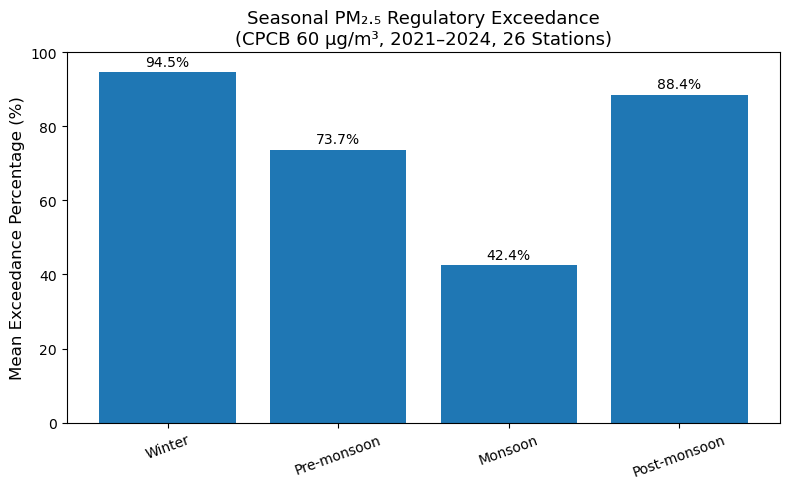

In [8]:
plt.figure(figsize=(8, 5))

seasons = network_mean.index
values = network_mean.values

bars = plt.bar(seasons, values)

plt.ylabel("Mean Exceedance Percentage (%)", fontsize=12)
plt.title("Seasonal PM₂.₅ Regulatory Exceedance\n(CPCB 60 µg/m³, 2021–2024, 26 Stations)", fontsize=13)

plt.xticks(rotation=20)
plt.ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("outputs/seasonal_exceedance_bar.png", dpi=300)
plt.show()

In [39]:
regions = {
    "North": [
        "station_1430_rohini_delhi_dpcc_1hr",
        "station_1423_jahangirpuri_delhi_dpcc_1hr",
        "station_1420_ashok_vihar_delhi_dpcc_1hr",
        "station_1434_wazirpur_delhi_dpcc_1hr",
        "station_1426_narela_delhi_dpcc_1hr",
        "station_1560_bawana_delhi_dpcc_1hr",
    ],
    
    "East": [
        "station_114_ihbas_dilshad_garden_delhi_cpcb_1hr",
        "station_301_anand_vihar_delhi_dpcc_1hr",
        "station_1431_patparganj_delhi_dpcc_1hr",
        "station_1435_vivek_vihar_delhi_dpcc_1hr",
        "station_1432_sonia_vihar_delhi_dpcc_1hr",
        "station_1563_pusa_delhi_dpcc_1hr",
    ],
    
    "South_Central" : [
    "station_122_mandir_marg_delhi_dpcc_1hr",
    "station_1424_jawaharlal_nehru_stadium_delhi_dpcc_1hr",
    "station_1425_major_dhyan_chand_national_stadium_delhi",  # corrected
    "station_124_r_k_puram_delhi_dpcc_1hr",
    "station_1428_okhla_phase_2_delhi_dpcc_1hr",
    "station_1429_nehru_nagar_delhi_dpcc_1hr",
    "station_1562_sri_aurobindo_marg_delhi_dpcc_1hr",
    "station_1421_dr__karni_singh_shooting_range_delhi_dpc"
],
    
    "West_SW": [
        "station_113_shadipur_delhi_cpcb_1hr",
        "station_115_nsit_dwarka_delhi_cpcb_1hr",
        "station_125_punjabi_bagh_delhi_dpcc_1hr",
        "station_1422_dwarka_sector_8_delhi_dpcc__1hr",
        "station_1427_najafgarh_delhi_dpcc_1hr",
        "station_1561_mundka_delhi_dpcc_1hr",
    ]
}

In [12]:
# Flatten list
all_region_stations = [s for region in regions.values() for s in region]

print("Total mapped stations:", len(all_region_stations))
print("Unique stations:", len(set(all_region_stations)))

# Check for duplicates
duplicates = [s for s in all_region_stations if all_region_stations.count(s) > 1]
print("Duplicates:", set(duplicates))

Total mapped stations: 26
Unique stations: 26
Duplicates: set()


In [13]:
import os
import pandas as pd

BASE_PATH = "../final_station_data_clean"
THRESHOLD = 60

results = []

for station in os.listdir(BASE_PATH):
    station_path = os.path.join(BASE_PATH, station)
    
    if not os.path.isdir(station_path):
        continue
    
    all_years_df = []

    for file in os.listdir(station_path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(station_path, file))
            all_years_df.append(df)

    station_df = pd.concat(all_years_df, ignore_index=True)

    seasonal_percentages = {}

    for season in ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]:
        season_df = station_df[station_df["season"] == season]
        valid_hours = season_df["PM 2.5"].notna().sum()
        exceed_hours = (season_df["PM 2.5"] > THRESHOLD).sum()

        percent = (exceed_hours / valid_hours) * 100 if valid_hours > 0 else None
        seasonal_percentages[season] = percent

    seasonal_percentages["Station"] = station
    results.append(seasonal_percentages)

result_df = pd.DataFrame(results)

In [14]:
def get_region(station_name):
    for region, stations in regions.items():
        if station_name in stations:
            return region
    return None

result_df["Region"] = result_df["Station"].apply(get_region)

result_df.head()

,Winter,Pre-monsoon,Monsoon,Post-monsoon,Station,Region
0,92.089414,74.012332,41.101108,83.136247,station_113_shadipur_delhi_cpcb_1hr,West_SW
1,88.334901,65.016779,32.820558,87.607513,station_114_ihbas_dilshad_garden_delhi_cpcb_1hr,East
2,89.788814,81.099735,31.346521,89.068687,station_115_nsit_dwarka_delhi_cpcb_1hr,West_SW
3,94.930547,70.678494,39.733142,87.187933,station_122_mandir_marg_delhi_dpcc_1hr,South_Central
4,96.148443,80.710426,54.274829,91.286674,station_124_r_k_puram_delhi_dpcc_1hr,South_Central


In [15]:
regional_mean = (
    result_df
    .groupby("Region")[["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]]
    .mean()
)

regional_mean

,Winter,Pre-monsoon,Monsoon,Post-monsoon
Region,,,,
East,94.871103,74.819874,47.486415,89.522824
North,96.286221,79.999022,52.970403,91.230509
South_Central,93.857671,68.701376,36.587933,86.443333
West_SW,93.096835,71.562124,33.522274,86.556097


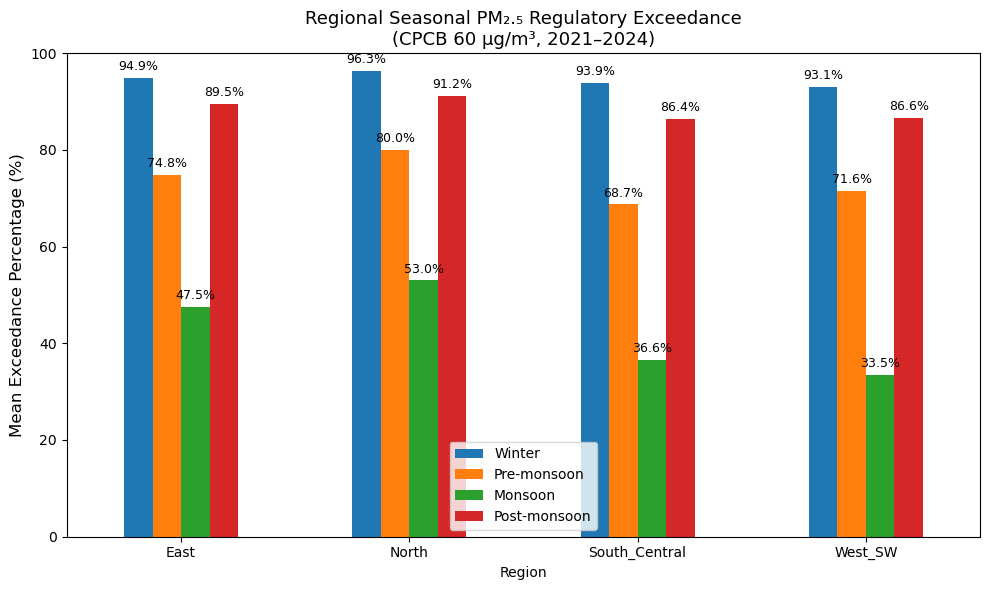

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

regional_mean.plot(kind="bar", ax=ax)

ax.set_ylabel("Mean Exceedance Percentage (%)", fontsize=12)
ax.set_title("Regional Seasonal PM₂.₅ Regulatory Exceedance\n(CPCB 60 µg/m³, 2021–2024)", fontsize=13)

ax.set_ylim(0, 100)
ax.set_xticklabels(regional_mean.index, rotation=0)

# Add percentage labels on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig("outputs/regional_seasonal_exceedance_bar.png", dpi=300)
plt.show()

In [18]:
!pip install windrose

Defaulting to user installation because normal site-packages is not writeable


In [19]:
from windrose import WindroseAxes

In [20]:
import os
import pandas as pd

BASE_PATH = "../final_station_data_clean"
THRESHOLD = 60

def load_region_data(region_name, season_filter=None):
    station_list = regions[region_name]
    all_data = []

    for station in station_list:
        station_path = os.path.join(BASE_PATH, station)
        
        for file in os.listdir(station_path):
            if file.endswith(".csv"):
                df = pd.read_csv(os.path.join(station_path, file))
                df["Station"] = station
                all_data.append(df)

    region_df = pd.concat(all_data, ignore_index=True)

    if season_filter:
        region_df = region_df[region_df["season"] == season_filter]

    return region_df

In [21]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes
import numpy as np

def plot_wind_rose(direction, speed, title):
    ax = WindroseAxes.from_ax()
    ax.bar(direction, speed, normed=True, opening=0.8, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_legend()
    plt.show()

In [22]:
region_name = "North"
season_name = "Winter"

region_df = load_region_data(region_name, season_name)

# Background wind
background_df = region_df.dropna(subset=["wind_dir", "wind_speed"])

# Exceedance wind
exceed_df = background_df[background_df["PM 2.5"] > THRESHOLD]

print("Total Winter Hours:", len(background_df))
print("Exceedance Hours:", len(exceed_df))

Total Winter Hours: 51475
Exceedance Hours: 49284


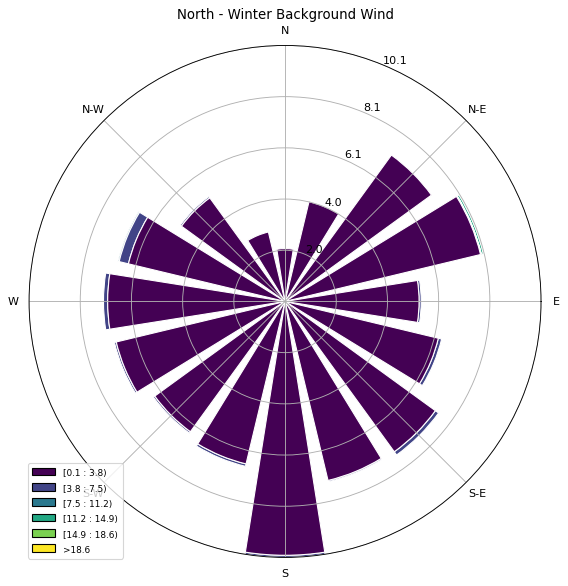

In [23]:
plot_wind_rose(
    background_df["wind_dir"],
    background_df["wind_speed"],
    f"{region_name} - {season_name} Background Wind"
)

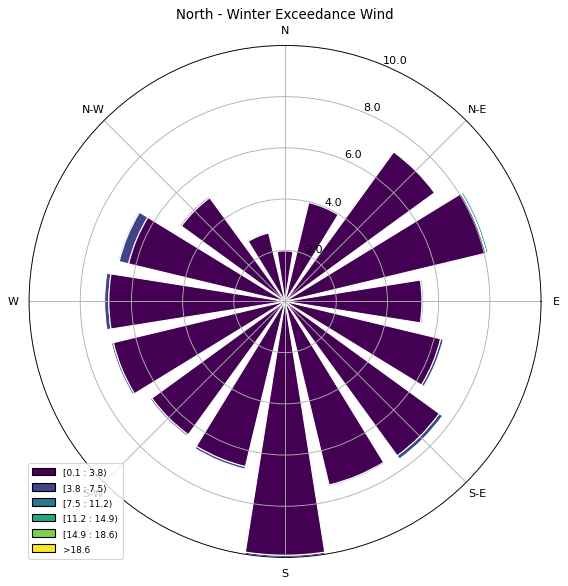

In [24]:
plot_wind_rose(
    exceed_df["wind_dir"],
    exceed_df["wind_speed"],
    f"{region_name} - {season_name} Exceedance Wind"
)

In [26]:
# Define percentile threshold (Top 15%)
extreme_threshold = background_df["PM 2.5"].quantile(0.85)

# Filter extreme pollution hours
extreme_df = background_df[background_df["PM 2.5"] >= extreme_threshold]

print("Extreme Threshold (µg/m³):", round(extreme_threshold, 2))
print("Total Winter Hours:", len(background_df))
print("Extreme Hours:", len(extreme_df))
print("Extreme Percentage:", round(len(extreme_df)/len(background_df)*100, 2), "%")

Extreme Threshold (µg/m³): 409.25
Total Winter Hours: 51475
Extreme Hours: 7680
Extreme Percentage: 14.92 %


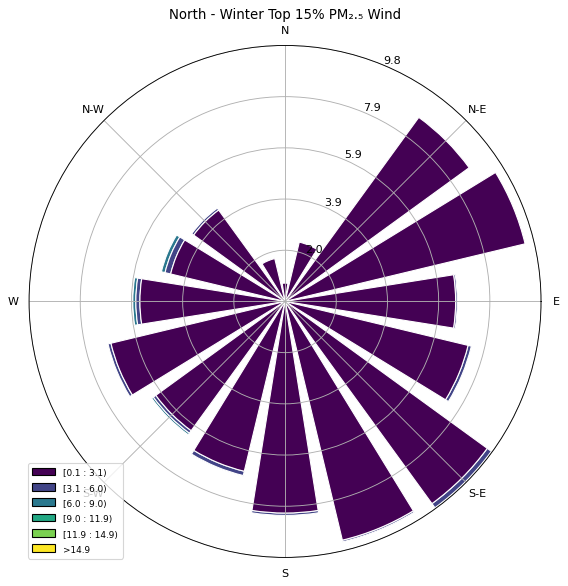

In [27]:
plot_wind_rose(
    extreme_df["wind_dir"],
    extreme_df["wind_speed"],
    f"{region_name} - {season_name} Top 15% PM₂.₅ Wind"
)

In [28]:
print("Background Mean Wind Speed:", round(background_df["wind_speed"].mean(),2))
print("Extreme Mean Wind Speed:", round(extreme_df["wind_speed"].mean(),2))

Background Mean Wind Speed: 0.96
Extreme Mean Wind Speed: 0.76


In [29]:
region_name = "East"
season_name = "Winter"

region_df = load_region_data(region_name, season_name)

# Background wind
background_df = region_df.dropna(subset=["wind_dir", "wind_speed"])

# Exceedance wind
exceed_df = background_df[background_df["PM 2.5"] > THRESHOLD]

print("Total Winter Hours:", len(background_df))
print("Exceedance Hours:", len(exceed_df))

Total Winter Hours: 51185
Exceedance Hours: 48280


In [30]:
#Define percentile threshold (Top 15%)
extreme_threshold = background_df["PM 2.5"].quantile(0.85)

# Filter extreme pollution hours
extreme_df = background_df[background_df["PM 2.5"] >= extreme_threshold]

print("Extreme Threshold (µg/m³):", round(extreme_threshold, 2))
print("Total Winter Hours:", len(background_df))
print("Extreme Hours:", len(extreme_df))
print("Extreme Percentage:", round(len(extreme_df)/len(background_df)*100, 2), "%")

Extreme Threshold (µg/m³): 369.75
Total Winter Hours: 51185
Extreme Hours: 7641
Extreme Percentage: 14.93 %


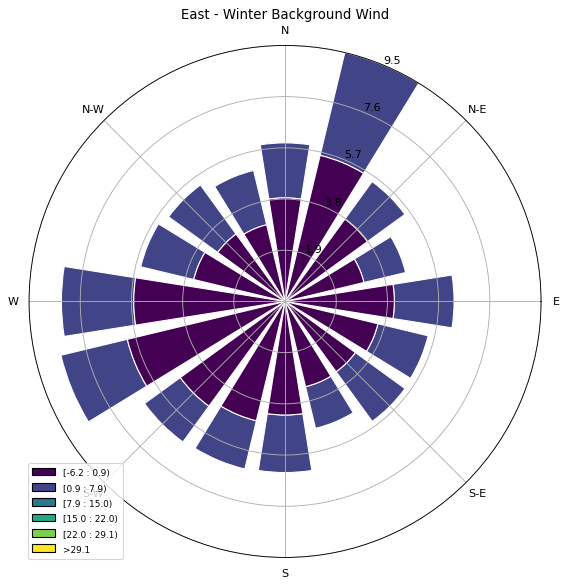

In [31]:
plot_wind_rose(
    background_df["wind_dir"],
    background_df["wind_speed"],
    f"{region_name} - {season_name} Background Wind"
)

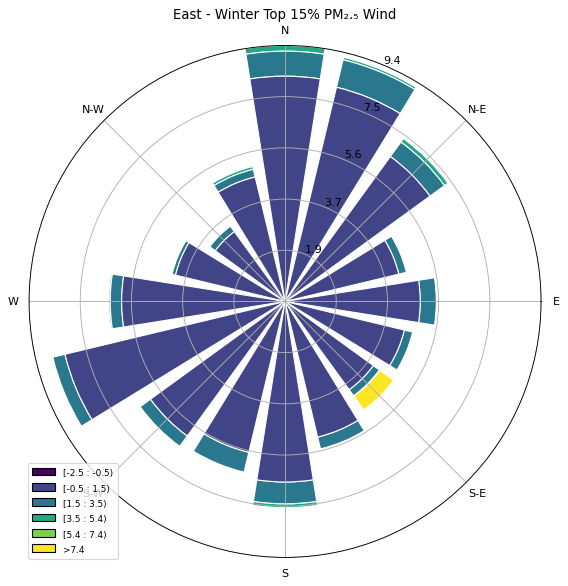

In [32]:
plot_wind_rose(
    extreme_df["wind_dir"],
    extreme_df["wind_speed"],
    f"{region_name} - {season_name} Top 15% PM₂.₅ Wind"
)

In [33]:
print("Background Mean Wind Speed:", round(background_df["wind_speed"].mean(),2))
print("Extreme Mean Wind Speed:", round(extreme_df["wind_speed"].mean(),2))

Background Mean Wind Speed: 0.88
Extreme Mean Wind Speed: 0.65


In [42]:
region_name = "South_Central"
season_name = "Winter"

region_df = load_region_data(region_name, season_name)

# Background wind
background_df = region_df.dropna(subset=["wind_dir", "wind_speed"])

# Exceedance wind
exceed_df = background_df[background_df["PM 2.5"] > THRESHOLD]

print("Total Winter Hours:", len(background_df))
print("Exceedance Hours:", len(exceed_df))

Total Winter Hours: 67948
Exceedance Hours: 63523


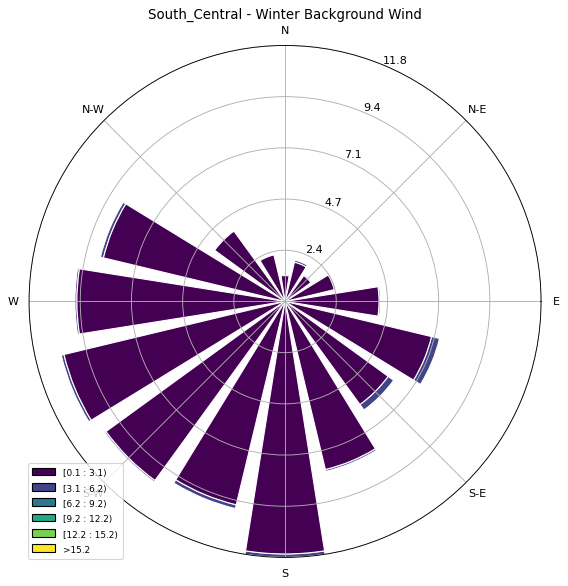

In [43]:
plot_wind_rose(
    background_df["wind_dir"],
    background_df["wind_speed"],
    f"{region_name} - {season_name} Background Wind"
)

In [44]:
# Define percentile threshold (Top 15%)
extreme_threshold = background_df["PM 2.5"].quantile(0.85)

# Filter extreme pollution hours
extreme_df = background_df[background_df["PM 2.5"] >= extreme_threshold]

print("Extreme Threshold (µg/m³):", round(extreme_threshold, 2))
print("Total Winter Hours:", len(background_df))
print("Extreme Hours:", len(extreme_df))
print("Extreme Percentage:", round(len(extreme_df)/len(background_df)*100, 2), "%")

Extreme Threshold (µg/m³): 328.0
Total Winter Hours: 67948
Extreme Hours: 10160
Extreme Percentage: 14.95 %


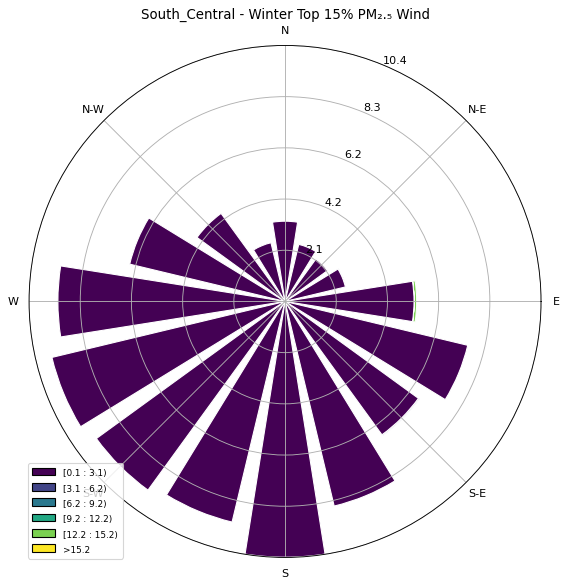

In [45]:
plot_wind_rose(
    extreme_df["wind_dir"],
    extreme_df["wind_speed"],
    f"{region_name} - {season_name} Top 15% PM₂.₅ Wind"
)

In [46]:
print("Background Mean Wind Speed:", round(background_df["wind_speed"].mean(),2))
print("Extreme Mean Wind Speed:", round(extreme_df["wind_speed"].mean(),2))

Background Mean Wind Speed: 0.95
Extreme Mean Wind Speed: 0.64


In [47]:
region_name = "West_SW"
season_name = "Winter"

region_df = load_region_data(region_name, season_name)

# Background wind
background_df = region_df.dropna(subset=["wind_dir", "wind_speed"])

# Exceedance wind
exceed_df = background_df[background_df["PM 2.5"] > THRESHOLD]

print("Total Winter Hours:", len(background_df))
print("Exceedance Hours:", len(exceed_df))

Total Winter Hours: 51145
Exceedance Hours: 47162


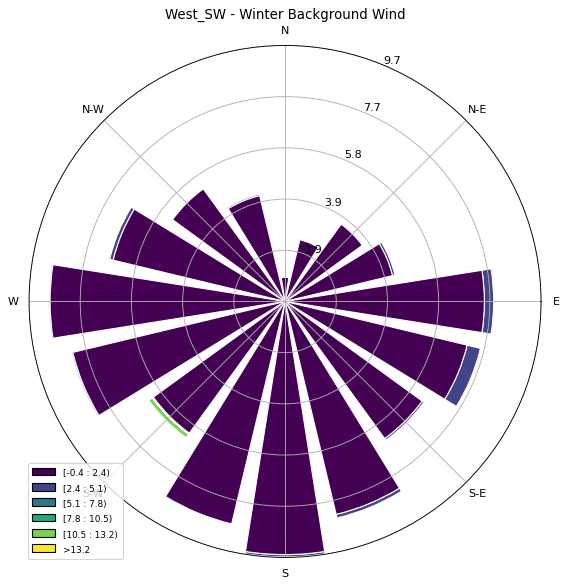

In [48]:
plot_wind_rose(
    background_df["wind_dir"],
    background_df["wind_speed"],
    f"{region_name} - {season_name} Background Wind"
)

In [49]:
# Define percentile threshold (Top 15%)
extreme_threshold = background_df["PM 2.5"].quantile(0.85)

# Filter extreme pollution hours
extreme_df = background_df[background_df["PM 2.5"] >= extreme_threshold]

print("Extreme Threshold (µg/m³):", round(extreme_threshold, 2))
print("Total Winter Hours:", len(background_df))
print("Extreme Hours:", len(extreme_df))
print("Extreme Percentage:", round(len(extreme_df)/len(background_df)*100, 2), "%")

Extreme Threshold (µg/m³): 290.03
Total Winter Hours: 51145
Extreme Hours: 7603
Extreme Percentage: 14.87 %


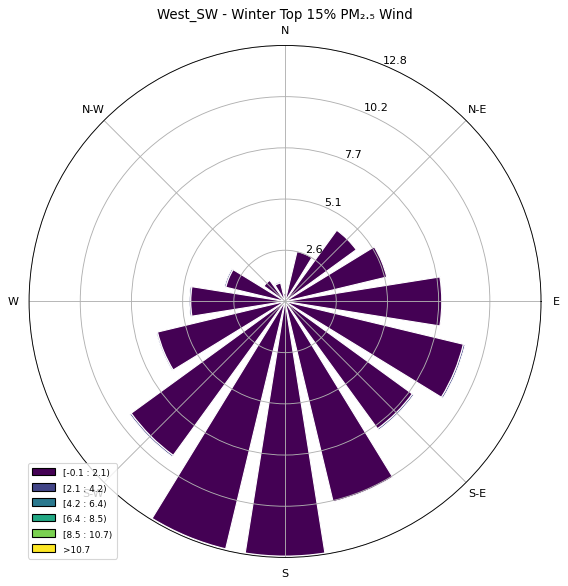

In [51]:
plot_wind_rose(
    extreme_df["wind_dir"],
    extreme_df["wind_speed"],
    f"{region_name} - {season_name} Top 15% PM₂.₅ Wind"
)

In [52]:
print("Background Mean Wind Speed:", round(background_df["wind_speed"].mean(),2))
print("Extreme Mean Wind Speed:", round(extreme_df["wind_speed"].mean(),2))

Background Mean Wind Speed: 0.71
Extreme Mean Wind Speed: 0.49



Processing North - Winter


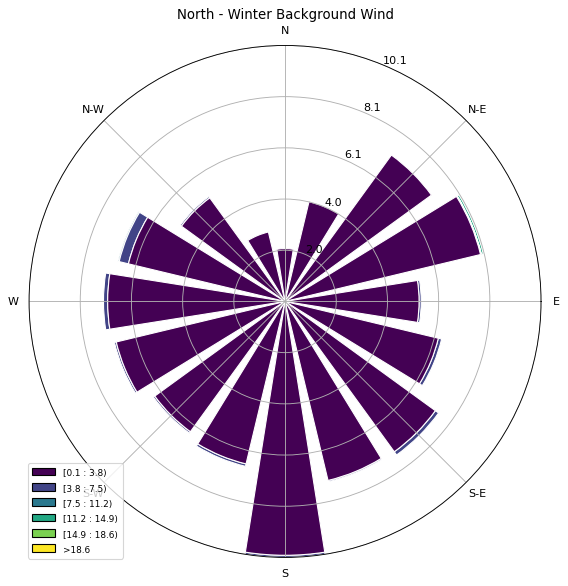

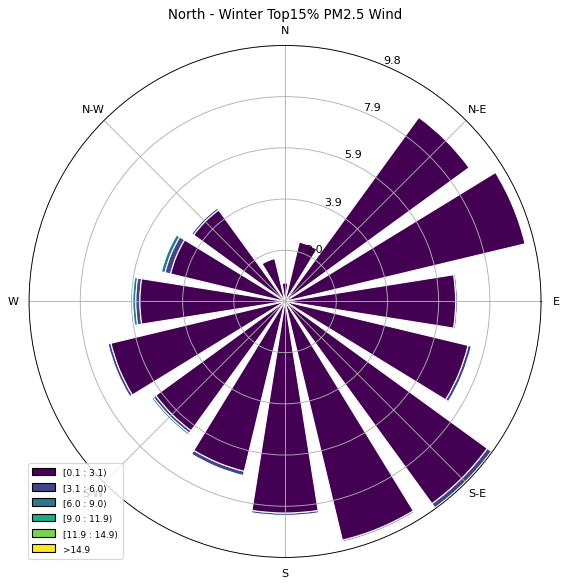


Processing North - Post-monsoon


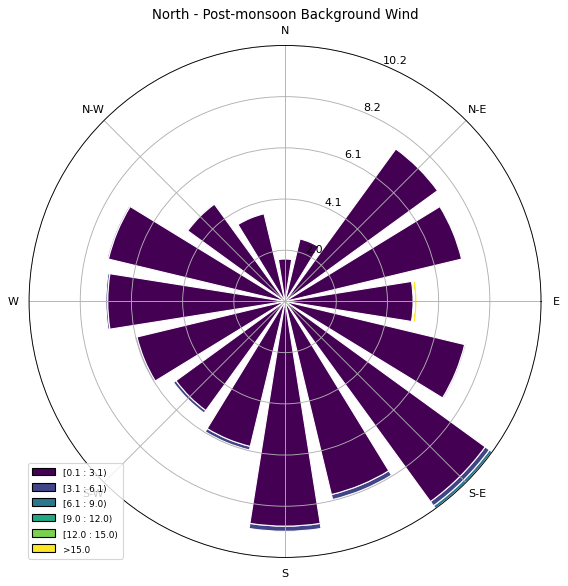

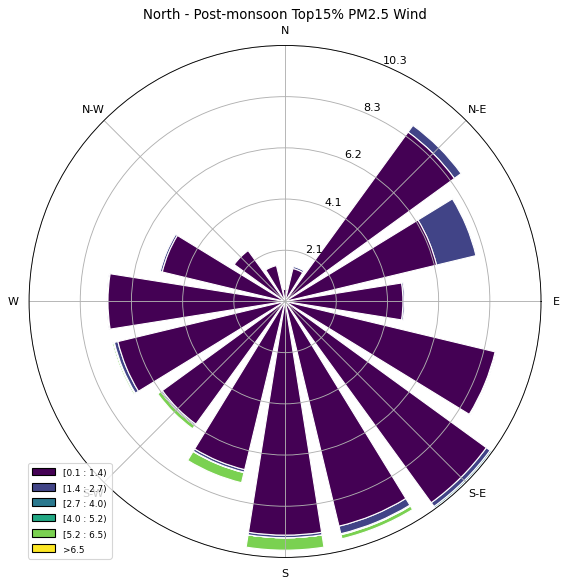


Processing North - Pre-monsoon


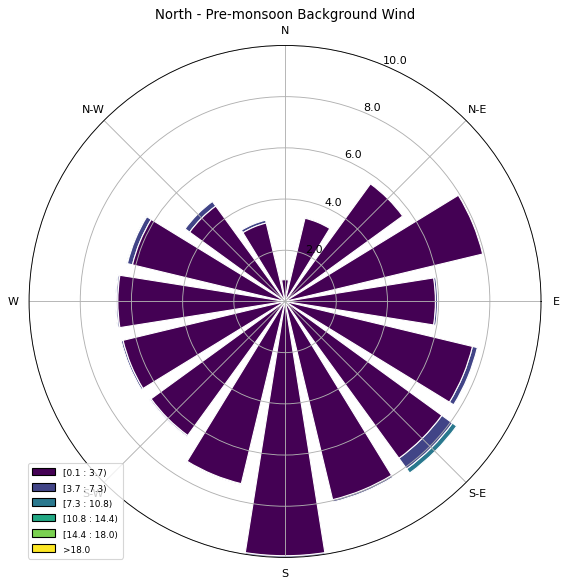

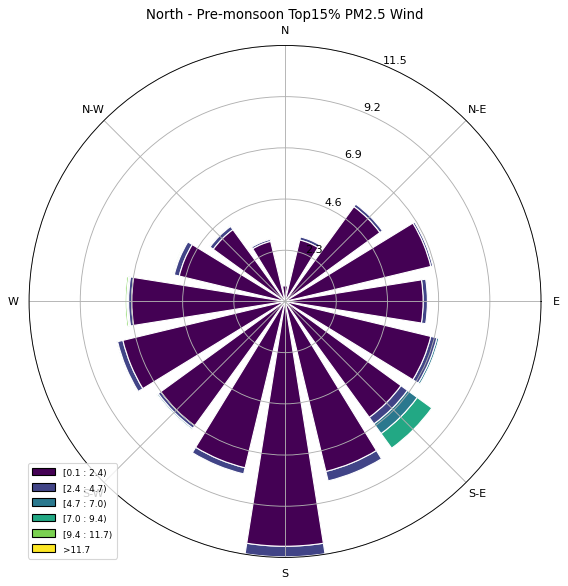


Processing North - Monsoon


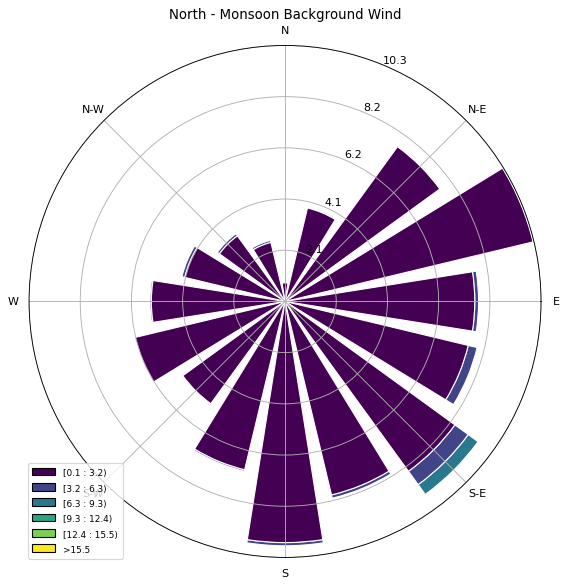

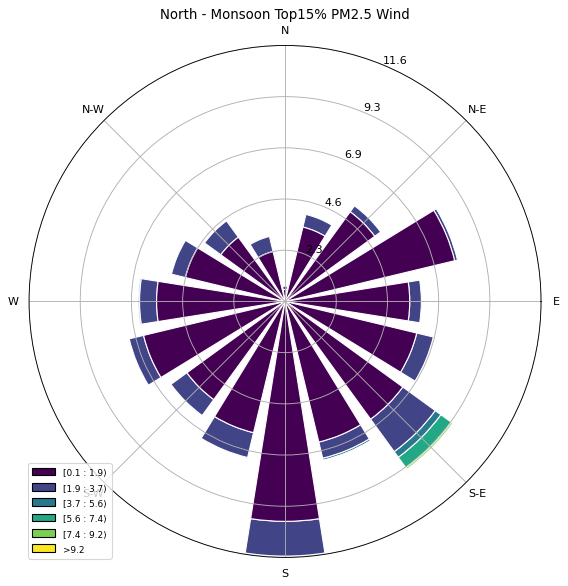


Processing East - Winter


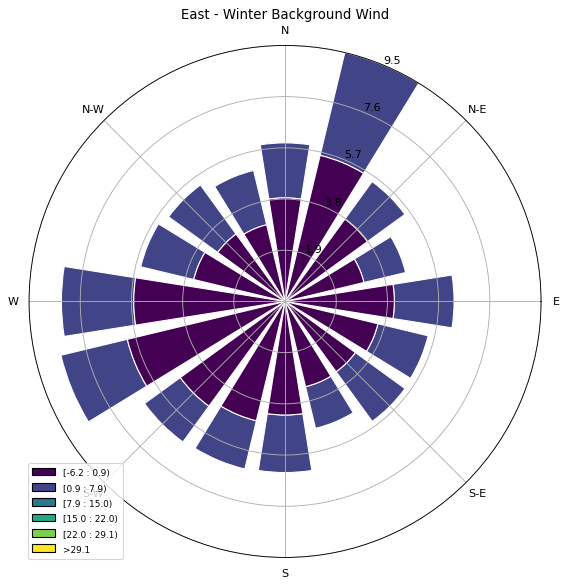

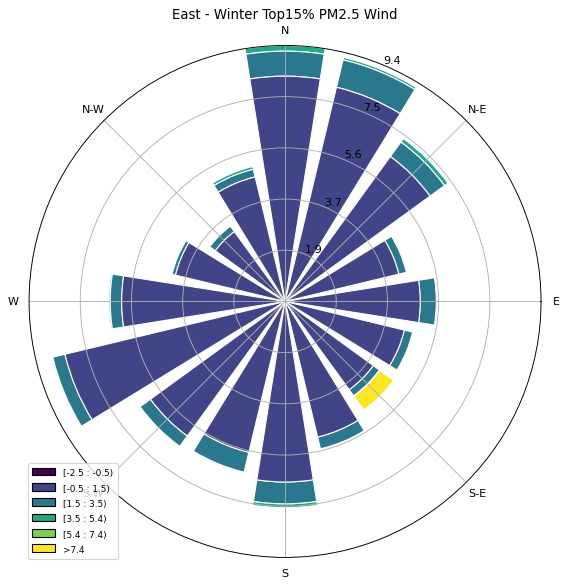


Processing East - Post-monsoon


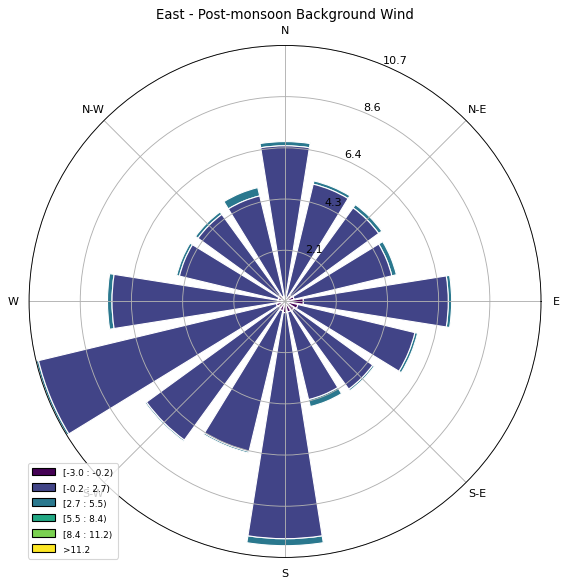

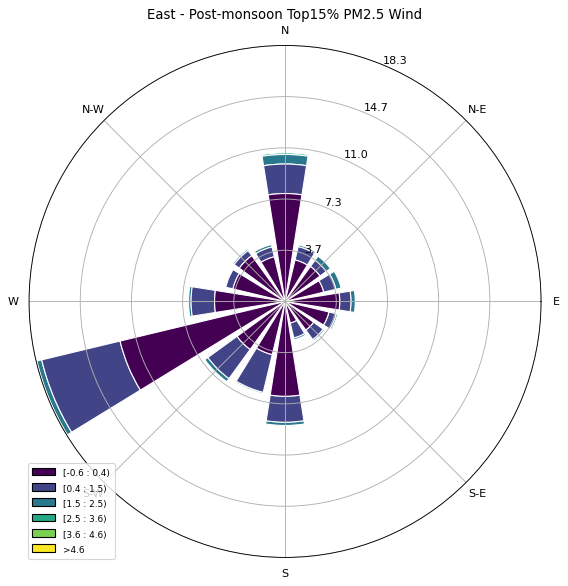


Processing East - Pre-monsoon


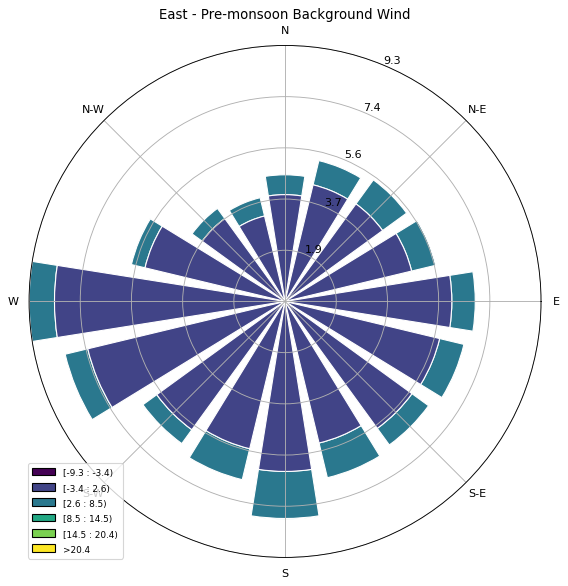

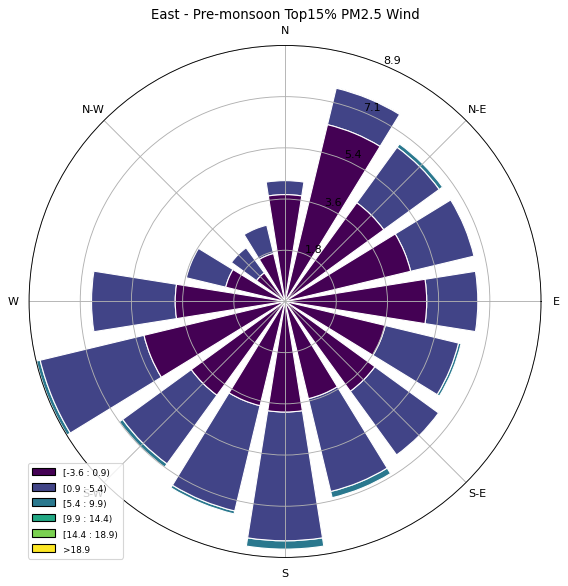


Processing East - Monsoon


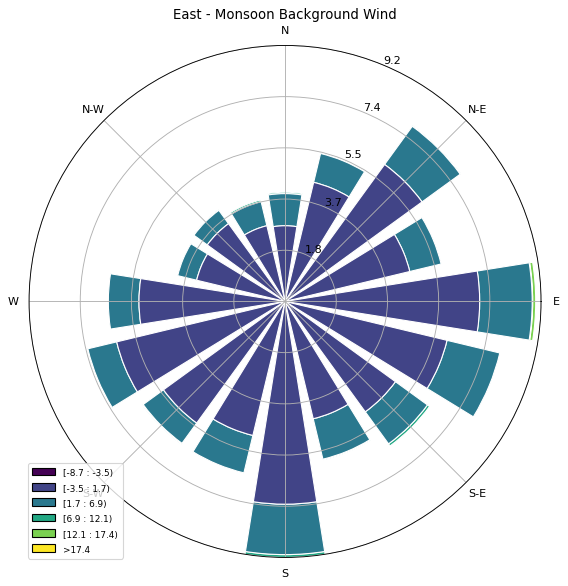

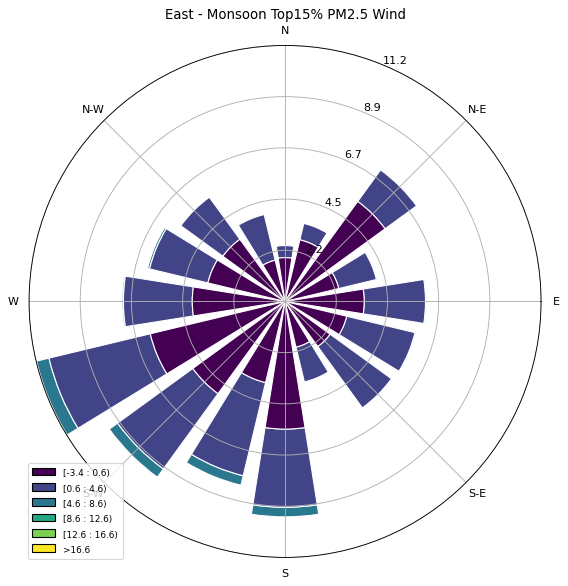


Processing South_Central - Winter


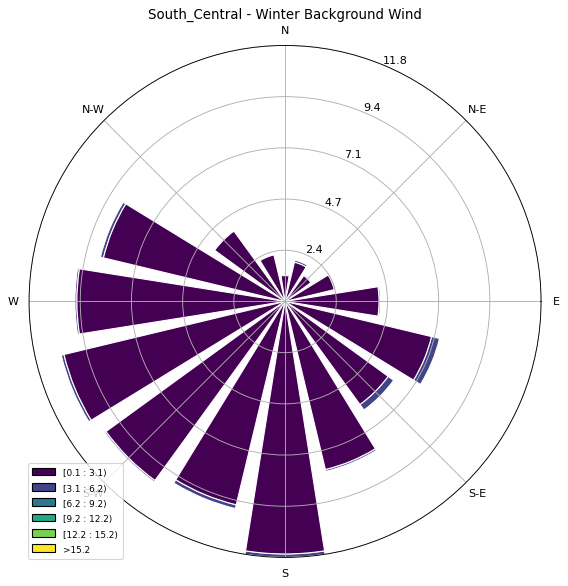

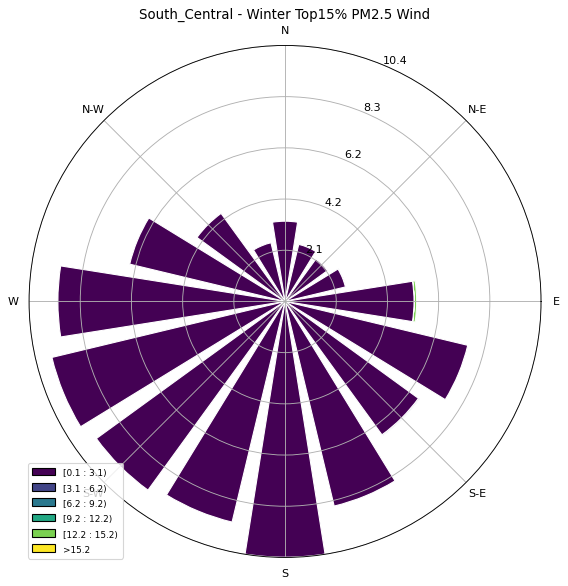


Processing South_Central - Post-monsoon


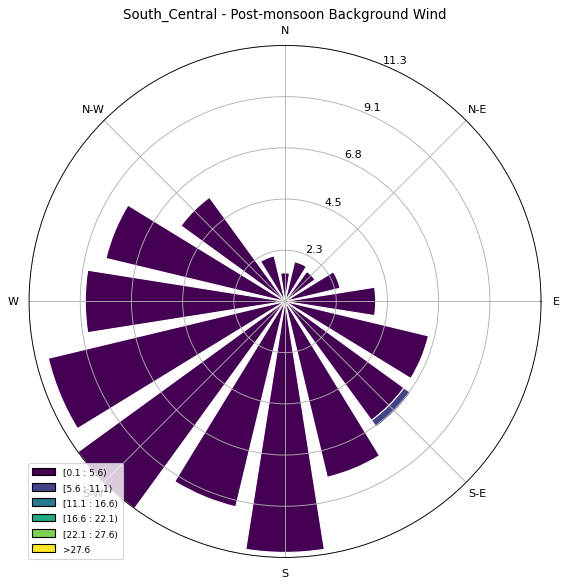

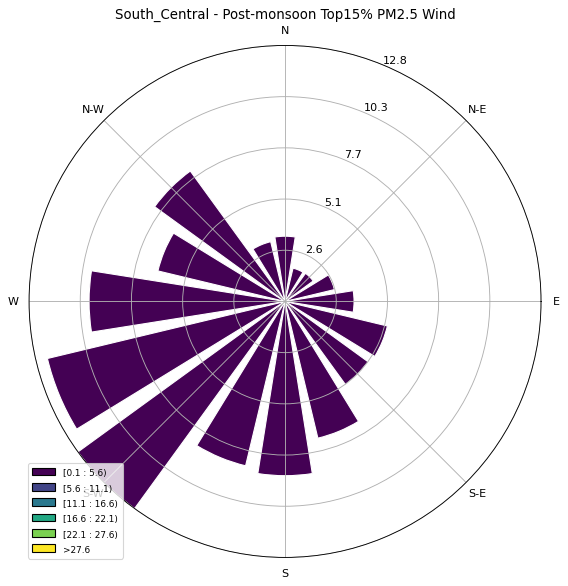


Processing South_Central - Pre-monsoon


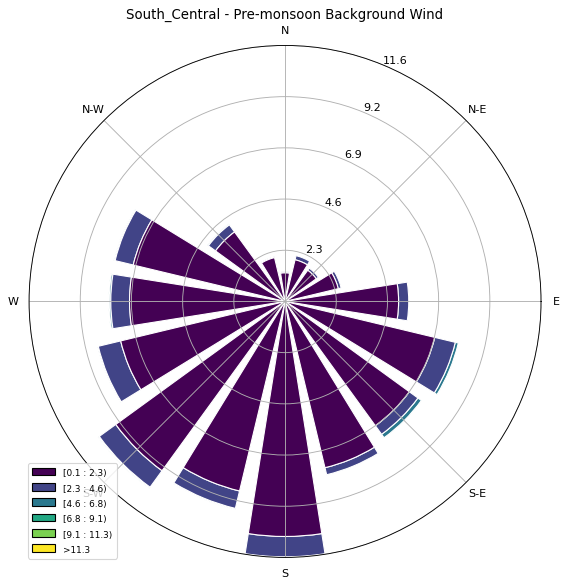

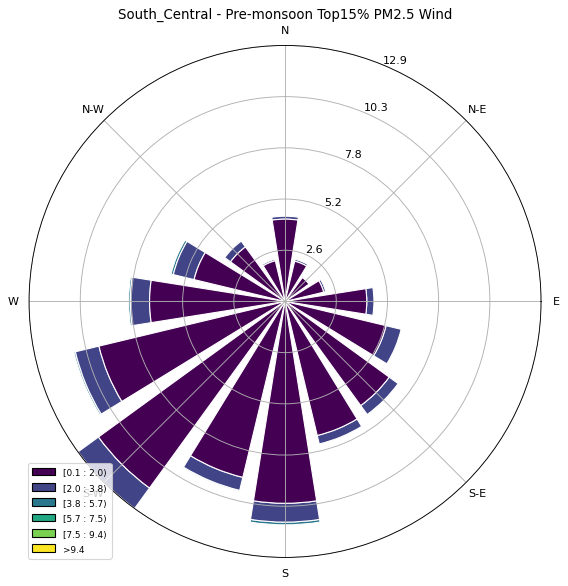


Processing South_Central - Monsoon


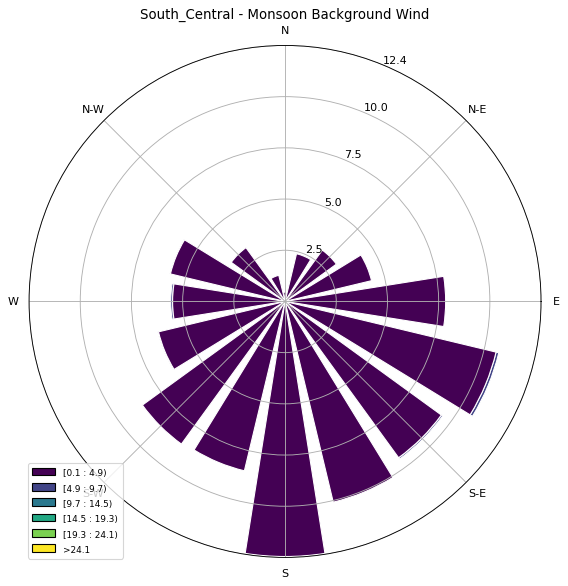

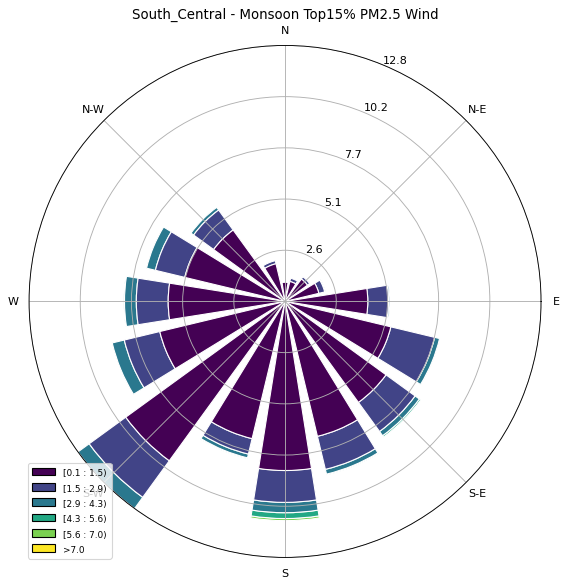


Processing West_SW - Winter


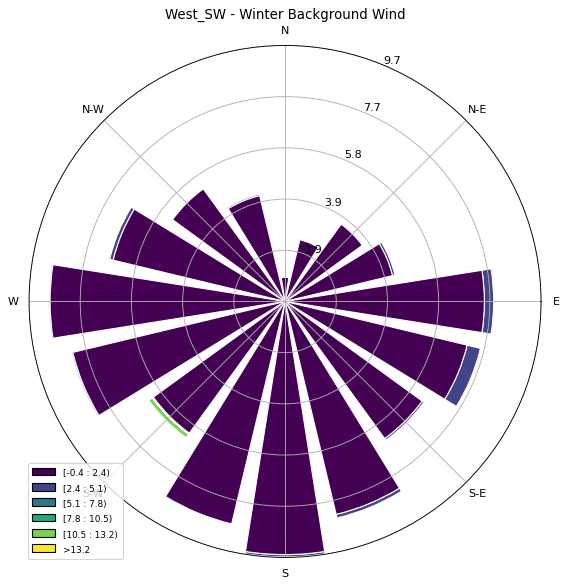

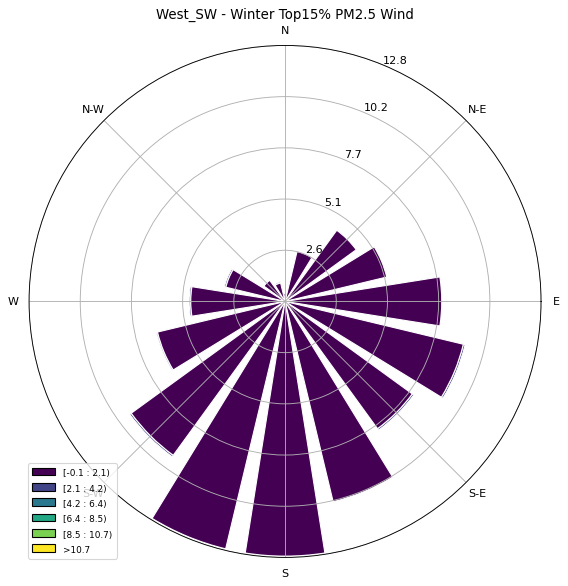


Processing West_SW - Post-monsoon


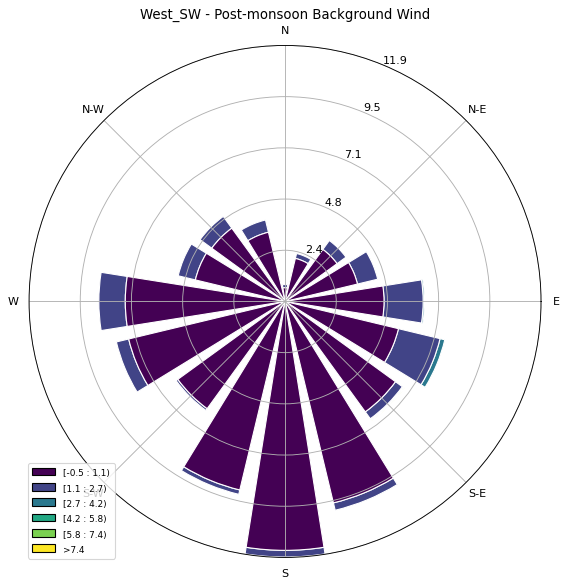

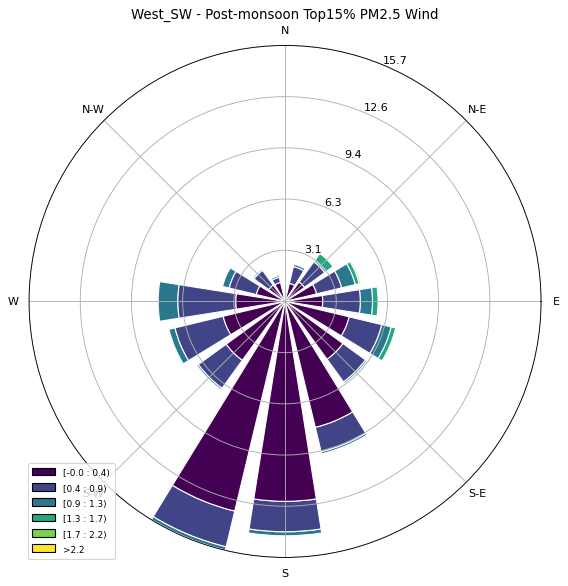


Processing West_SW - Pre-monsoon


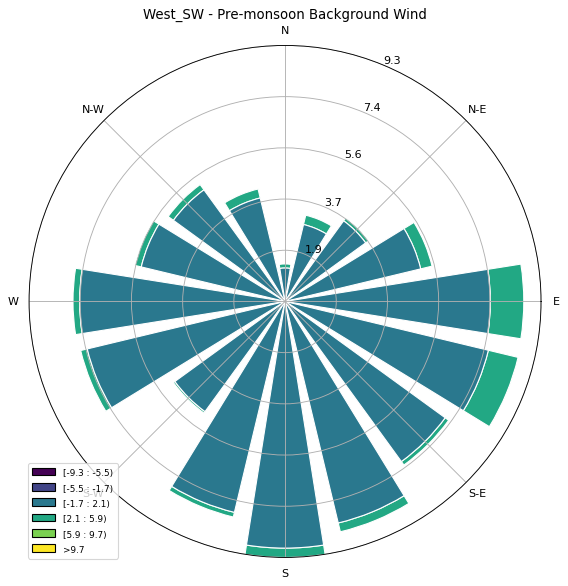

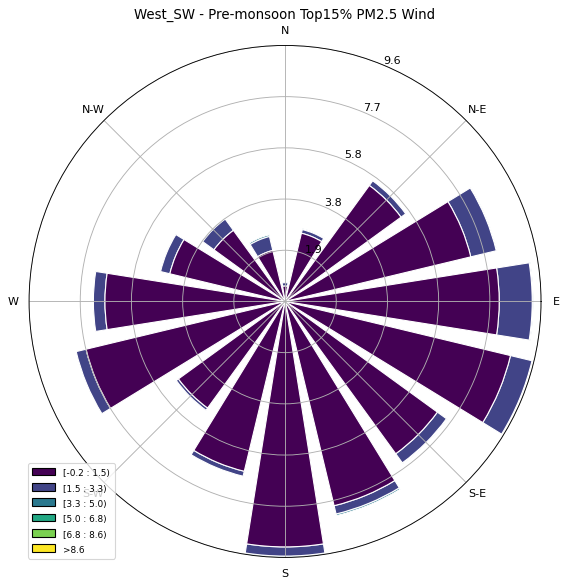


Processing West_SW - Monsoon


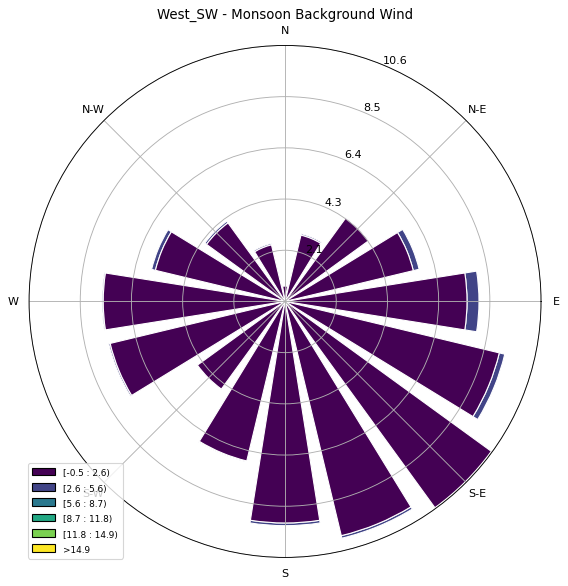

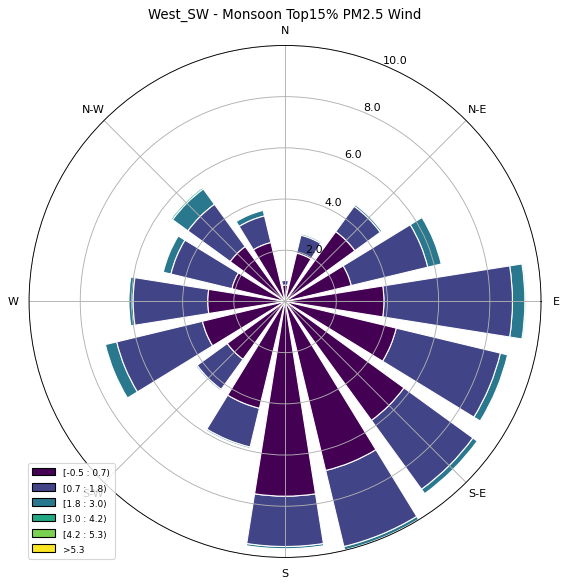


All regions processed. Summary saved.


In [54]:
import os
import pandas as pd
import numpy as np

# Ensure output folder exists
os.makedirs("outputs/wind_analysis", exist_ok=True)

results_summary = []

regions_list = ["North", "East", "South_Central", "West_SW"]
seasons_list = ["Winter","Post-monsoon","Pre-monsoon","Monsoon"]  

for region_name in regions_list:
    for season_name in seasons_list:

        print(f"\nProcessing {region_name} - {season_name}")

        region_df = load_region_data(region_name, season_name)
        background_df = region_df.dropna(subset=["wind_dir", "wind_speed"])

        # ---- Percentile Threshold ----
        extreme_threshold = background_df["PM 2.5"].quantile(0.85)
        extreme_df = background_df[background_df["PM 2.5"] >= extreme_threshold]

        # ---- Wind Speed Stats ----
        bg_ws = background_df["wind_speed"].mean()
        ex_ws = extreme_df["wind_speed"].mean()

        ws_drop = ((bg_ws - ex_ws) / bg_ws) * 100

        results_summary.append({
            "Region": region_name,
            "Season": season_name,
            "Threshold": round(extreme_threshold,2),
            "Background_WS": round(bg_ws,2),
            "Extreme_WS": round(ex_ws,2),
            "WindSpeed_Drop_%": round(ws_drop,2)
        })

        # ---- Save Background Wind Rose ----
        plot_wind_rose(
            background_df["wind_dir"],
            background_df["wind_speed"],
            f"{region_name} - {season_name} Background Wind"
        )
        plt.savefig(f"outputs/wind_analysis/{region_name}_{season_name}_background.png", dpi=300)
        plt.close()

        # ---- Save Extreme Wind Rose ----
        plot_wind_rose(
            extreme_df["wind_dir"],
            extreme_df["wind_speed"],
            f"{region_name} - {season_name} Top15% PM2.5 Wind"
        )
        plt.savefig(f"outputs/wind_analysis/{region_name}_{season_name}_top15.png", dpi=300)
        plt.close()

# ---- Save Summary Table ----
summary_df = pd.DataFrame(results_summary)
summary_df.to_csv("outputs/wind_analysis/winter_wind_summary.csv", index=False)

print("\nAll regions processed. Summary saved.")

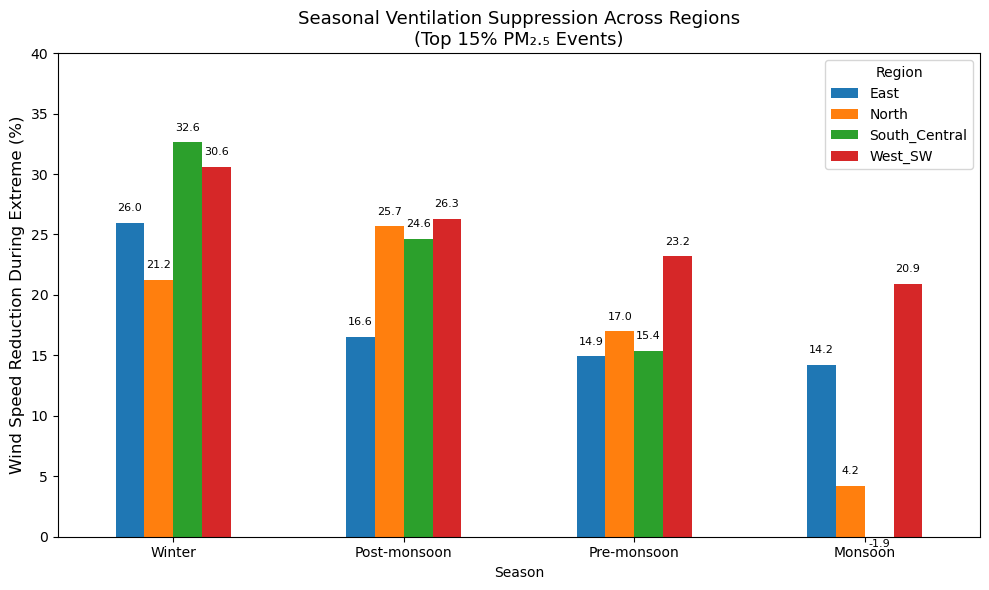

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load summary file
summary_df = pd.read_csv("outputs/wind_analysis/winter_wind_summary.csv")

# Pivot table: rows = Season, columns = Region
pivot_df = summary_df.pivot(index="Season", columns="Region", values="WindSpeed_Drop_%")

# Ensure season order
season_order = ["Winter", "Post-monsoon", "Pre-monsoon", "Monsoon"]
pivot_df = pivot_df.reindex(season_order)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

pivot_df.plot(kind="bar", ax=ax)

ax.set_ylabel("Wind Speed Reduction During Extreme (%)", fontsize=12)
ax.set_title("Seasonal Ventilation Suppression Across Regions\n(Top 15% PM₂.₅ Events)", fontsize=13)

ax.set_ylim(0, 40)
ax.set_xticklabels(pivot_df.index, rotation=0)

# Add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.8,
            f"{height:.1f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.savefig("outputs/wind_analysis/seasonal_windspeed_drop_comparison.png", dpi=300)
plt.show()